### Imports and Data Loading

In [6]:
import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {0: "#2196F3", 1: "#F44336", 2: "#FF9800"}
LABEL_NAME = {0: "Normal", 1: "Leak", 2: "Blockage"}
CMAP = "coolwarm"

DATA_DIR   = Path.cwd().parent.parent / "data" / "raw"
OUTPUT_DIR = Path.cwd().parent.parent / "assets" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### Load, combine

In [7]:
normal   = pd.read_csv(DATA_DIR / "normal_combined.csv")
leak     = pd.read_csv(DATA_DIR / "leak_combined.csv")
blockage = pd.read_csv(DATA_DIR / "blockage_combined.csv")

df = pd.concat([normal, leak, blockage], ignore_index=True)

FEATURES = ["pressure_A", "pressure_B", "pressure_C",
            "velocity_A", "velocity_B", "velocity_C"]

print("=" * 55)
print("  COMBINED DATASET SUMMARY")
print("=" * 55)
print(f"  Total rows  : {len(df):,}")
print(f"  Columns     : {list(df.columns)}")
print()
print(df.groupby(["label", "scenario"])["run_id"].count()
        .rename("rows").reset_index().to_string(index=False))
print("=" * 55)

df.to_csv(DATA_DIR / "copper_tailings_pipeline_data.csv", index=False)

print("\nSaved: copper_tailings_pipeline_data.csv")


  COMBINED DATASET SUMMARY
  Total rows  : 151,416
  Columns     : ['run_id', 'timestep', 'time_s', 'pressure_A', 'pressure_B', 'pressure_C', 'velocity_A', 'velocity_B', 'velocity_C', 'label', 'scenario']

 label       scenario  rows
     0         normal 50472
     1  leak_critical 16824
     1 leak_incipient 16824
     1  leak_moderate 16824
     2    blockage_25 16824
     2    blockage_50 16824
     2    blockage_75 16824

Saved: copper_tailings_pipeline_data.csv


In [8]:
df.head(10)

,run_id,timestep,time_s,pressure_A,pressure_B,pressure_C,velocity_A,velocity_B,velocity_C,label,scenario
0,0,0,0.0,0.007812,0.007812,0.007812,2.951487,2.963145,2.949855,0,normal
1,0,1,0.1,117246.900000,58469.720000,359.566900,2.947447,2.952487,2.940701,0,normal
2,0,2,0.2,101416.800000,50775.800000,300.451400,2.948791,2.953200,2.941500,0,normal
3,0,3,0.3,88645.910000,44387.200000,253.575200,2.949434,2.953305,2.941705,0,normal
4,0,4,0.4,82063.770000,41106.620000,224.899000,2.949710,2.953260,2.941774,0,normal
5,0,5,0.5,78725.090000,39421.350000,208.390800,2.949816,2.953166,2.941785,0,normal
6,0,6,0.6,77244.900000,38672.990000,198.614300,2.949866,2.953143,2.941715,0,normal
7,0,7,0.7,76636.210000,38373.760000,193.834900,2.949900,2.953127,2.941692,0,normal
8,0,8,0.8,76362.770000,38233.630000,191.487400,2.949922,2.953126,2.941698,0,normal
9,0,9,0.9,76258.660000,38173.730000,189.966700,2.949936,2.953139,2.941686,0,normal


In [9]:
df.tail(10)

,run_id,timestep,time_s,pressure_A,pressure_B,pressure_C,velocity_A,velocity_B,velocity_C,label,scenario
151406,71,691,69.1,107145.740421,96658.631073,132.183009,3.000756,3.000504,12.001461,2,blockage_75
151407,71,692,69.2,107129.333465,96652.506895,133.524855,3.000539,3.000435,12.001619,2,blockage_75
151408,71,693,69.3,107124.352167,96655.637543,132.568379,3.000535,3.000298,12.001199,2,blockage_75
151409,71,694,69.4,107129.323958,96659.213737,132.008173,3.000464,3.000228,12.001776,2,blockage_75
151410,71,695,69.5,107130.669744,96655.249917,133.062524,3.000546,3.000377,12.001248,2,blockage_75
151411,71,696,69.6,107118.545790,96633.207077,133.004958,3.000384,3.000793,12.002479,2,blockage_75
151412,71,697,69.7,107141.984277,96657.873378,133.687411,3.000443,3.000485,12.001642,2,blockage_75
151413,71,698,69.8,107138.580843,96657.740431,133.088825,3.000354,3.000383,12.001345,2,blockage_75
151414,71,699,69.9,107145.998603,96652.726423,132.291162,3.000526,3.000492,12.001980,2,blockage_75
151415,71,700,70.0,107147.465778,96651.250714,133.044850,3.000671,3.000262,12.002098,2,blockage_75


In [10]:
#Print the shape of each
print(f"Sensor data: {df.shape}")

Sensor data: (151416, 11)


In [11]:
# Checking their datatypes
print("="*80)
print("Sensor data types")
print("="*80)
print(df.dtypes)


Sensor data types
run_id          int64
timestep        int64
time_s        float64
pressure_A    float64
pressure_B    float64
pressure_C    float64
velocity_A    float64
velocity_B    float64
velocity_C    float64
label           int64
scenario       object
dtype: object


In [12]:
df.columns

Index(['run_id', 'timestep', 'time_s', 'pressure_A', 'pressure_B',
       'pressure_C', 'velocity_A', 'velocity_B', 'velocity_C', 'label',
       'scenario'],
      dtype='object')

In [13]:
# Check for null values in the dataset
df.isnull().sum()

run_id        0
timestep      0
time_s        0
pressure_A    0
pressure_B    0
pressure_C    0
velocity_A    0
velocity_B    0
velocity_C    0
label         0
scenario      0
dtype: int64

In [14]:
# Check duplicated rows in the dataset
df[df.duplicated()]

,run_id,timestep,time_s,pressure_A,pressure_B,pressure_C,velocity_A,velocity_B,velocity_C,label,scenario


### Descriptive statistics table

In [15]:
df.describe()

,run_id,timestep,time_s,pressure_A,pressure_B,pressure_C,velocity_A,velocity_B,velocity_C,label
count,151416.000000,151416.000000,151416.000000,151416.000000,151416.000000,151416.000000,151416.000000,151416.000000,151416.000000,151416.000000
mean,35.500000,350.000000,35.000000,81349.015432,42011.724827,168.043107,3.464038,3.435007,3.417601,1.000000
std,20.782674,202.361732,20.236173,11089.360187,14858.863275,31.105334,1.774945,1.785841,1.790871,0.816499
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.942504,2.506982,2.507014,0.000000
25%,17.750000,175.000000,17.500000,76526.623388,38115.877251,133.023609,2.951187,2.952836,2.940487,0.000000
50%,35.500000,350.000000,35.000000,76587.820864,38318.892182,184.160885,2.999166,2.984400,2.948816,1.000000
75%,53.250000,525.000000,52.500000,80549.968120,39364.706132,189.356054,3.000994,3.000739,2.999394,2.000000
max,71.000000,700.000000,70.000000,163945.257956,146775.673926,359.566900,12.008545,12.010260,12.007195,2.000000


In [16]:
stats = df.groupby("label")[FEATURES].agg(["mean", "std", "min", "max"])
stats.index = [LABEL_NAME[i] for i in stats.index]
print("\n=== DESCRIPTIVE STATISTICS PER CLASS ===")
display(stats)


=== DESCRIPTIVE STATISTICS PER CLASS ===


pressure_A                                      pressure_B  \
                  mean           std  min            max          mean   
Normal    77245.074730   4930.498294  0.0  117246.900000  38669.232983   
Leak      77451.132678   5251.294733  0.0  117311.468157  36574.074763   
Blockage  89350.838888  14865.187187  0.0  163945.257956  50791.866733   

                                            pressure_C             ...  \
                   std  min            max        mean        std  ...   
Normal     2450.317203  0.0   58469.720000  192.704168  18.123628  ...   
Leak       4642.658229  0.0   58437.632354  176.620855  25.137215  ...   
Blockage  22737.070088  0.0  146775.673926  134.804298  12.478734  ...   

         velocity_A            velocity_B                                 \
                min        max       mean       std       min        max   
Normal     2.942504   2.956729   2.953186  0.001780  2.946793   2.963145   
Leak       2.946658   3.003759   2.909506  0.164772  2.506982   3.003788   
Blockage   2.946658  12.008545   4.442328  2.831542  2.946658  12.010260   

         velocity_C                                 
               mean       std       min        max  
Normal     2.941710  0.001758  2.935081   2.949855  
Leak       2.868658  0.160653  2.507014   2.997718  
Blockage   4.442434  2.831581  2.946658  12.007195  

[3 rows x 24 columns]

### Class distribution bar chart

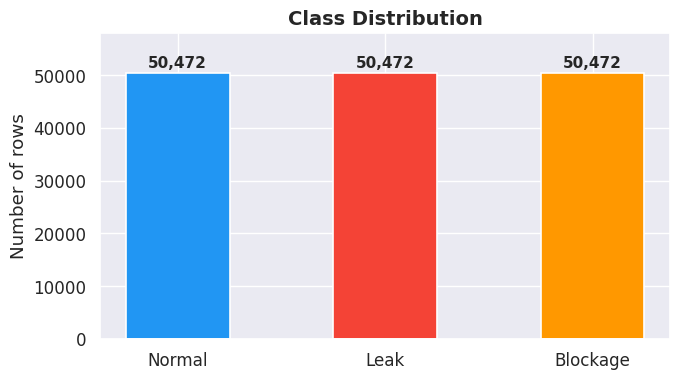


Saved: 01_class_distribution.png


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df["label"].value_counts().sort_index()
bars = ax.bar([LABEL_NAME[i] for i in counts.index],
              counts.values,
              color=[PALETTE[i] for i in counts.index],
              edgecolor="white", linewidth=1.2, width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of rows")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=150)
plt.close()
print("\nSaved: 01_class_distribution.png")

### Steady-state box plots 

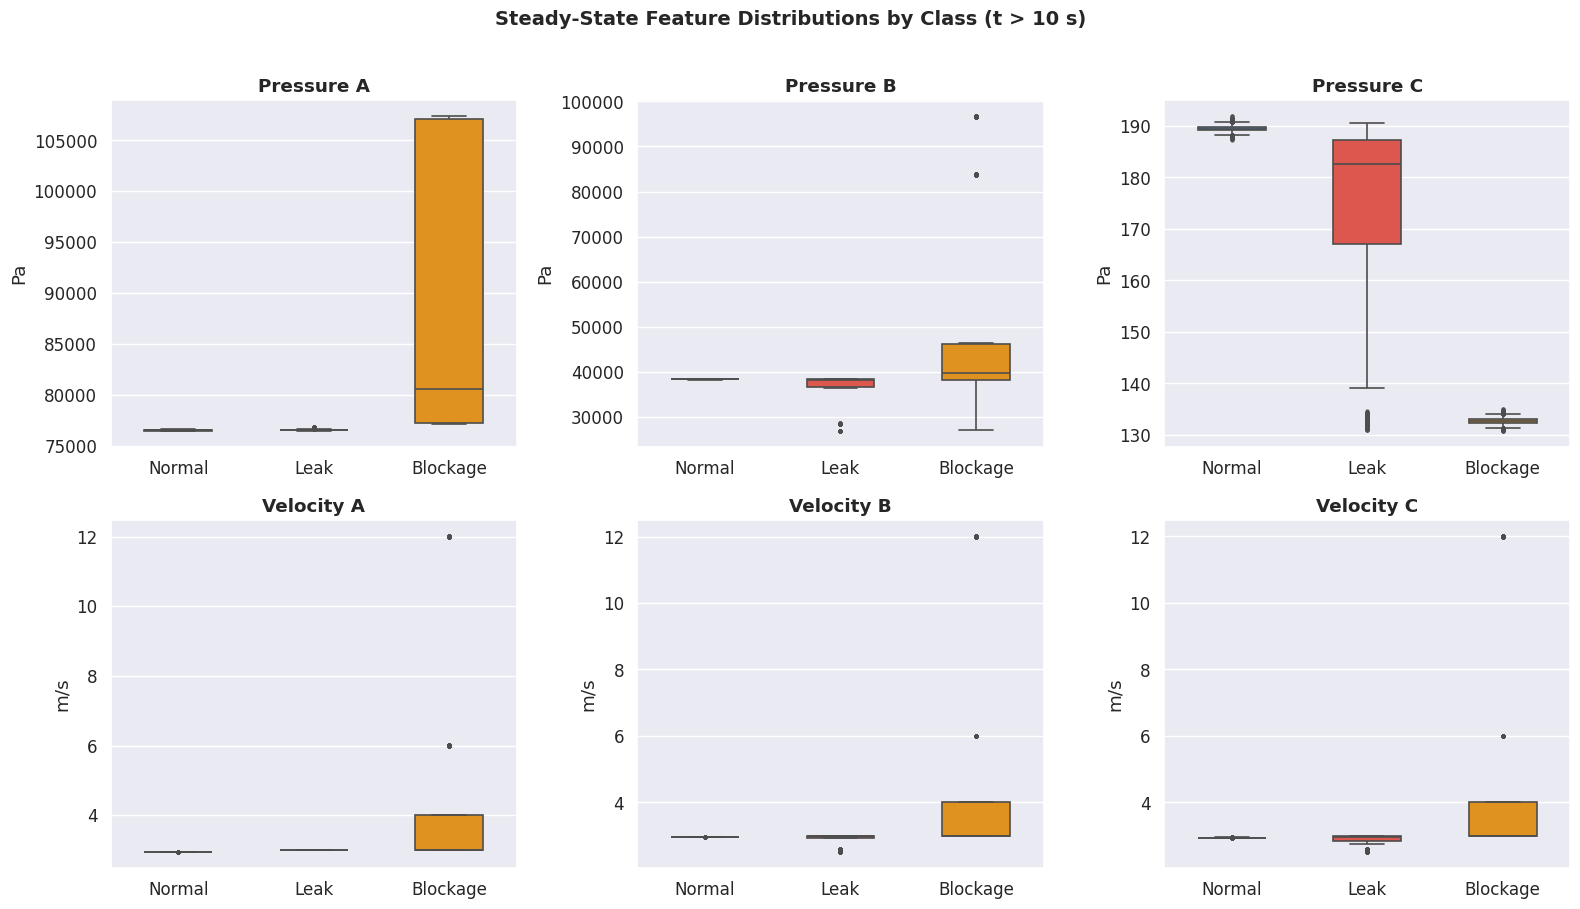

Saved: 02_boxplots_steadystate.png


In [18]:
CLASS_PALETTE = {
    "Normal": "#2196F3",
    "Leak": "#F44336",
    "Blockage": "#FF9800"
}

ss = df[df["time_s"] > 10].copy()
ss["Class"] = ss["label"].map(LABEL_NAME)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feat in zip(axes.flatten(), FEATURES):

    sns.boxplot(
        data=ss,
        x="Class",
        y=feat,
        hue="Class",
        palette=CLASS_PALETTE,
        order=["Normal", "Leak", "Blockage"],
        ax=ax,
        width=0.5,
        linewidth=1.2,
        fliersize=2,
        legend=False
    )

    ax.set_title(
        feat.replace("_", " ").title(),
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("Pa" if "pressure" in feat else "m/s")

plt.suptitle(
    "Steady-State Feature Distributions by Class (t > 10 s)",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_boxplots_steadystate.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved: 02_boxplots_steadystate.png")

### Time-series trends

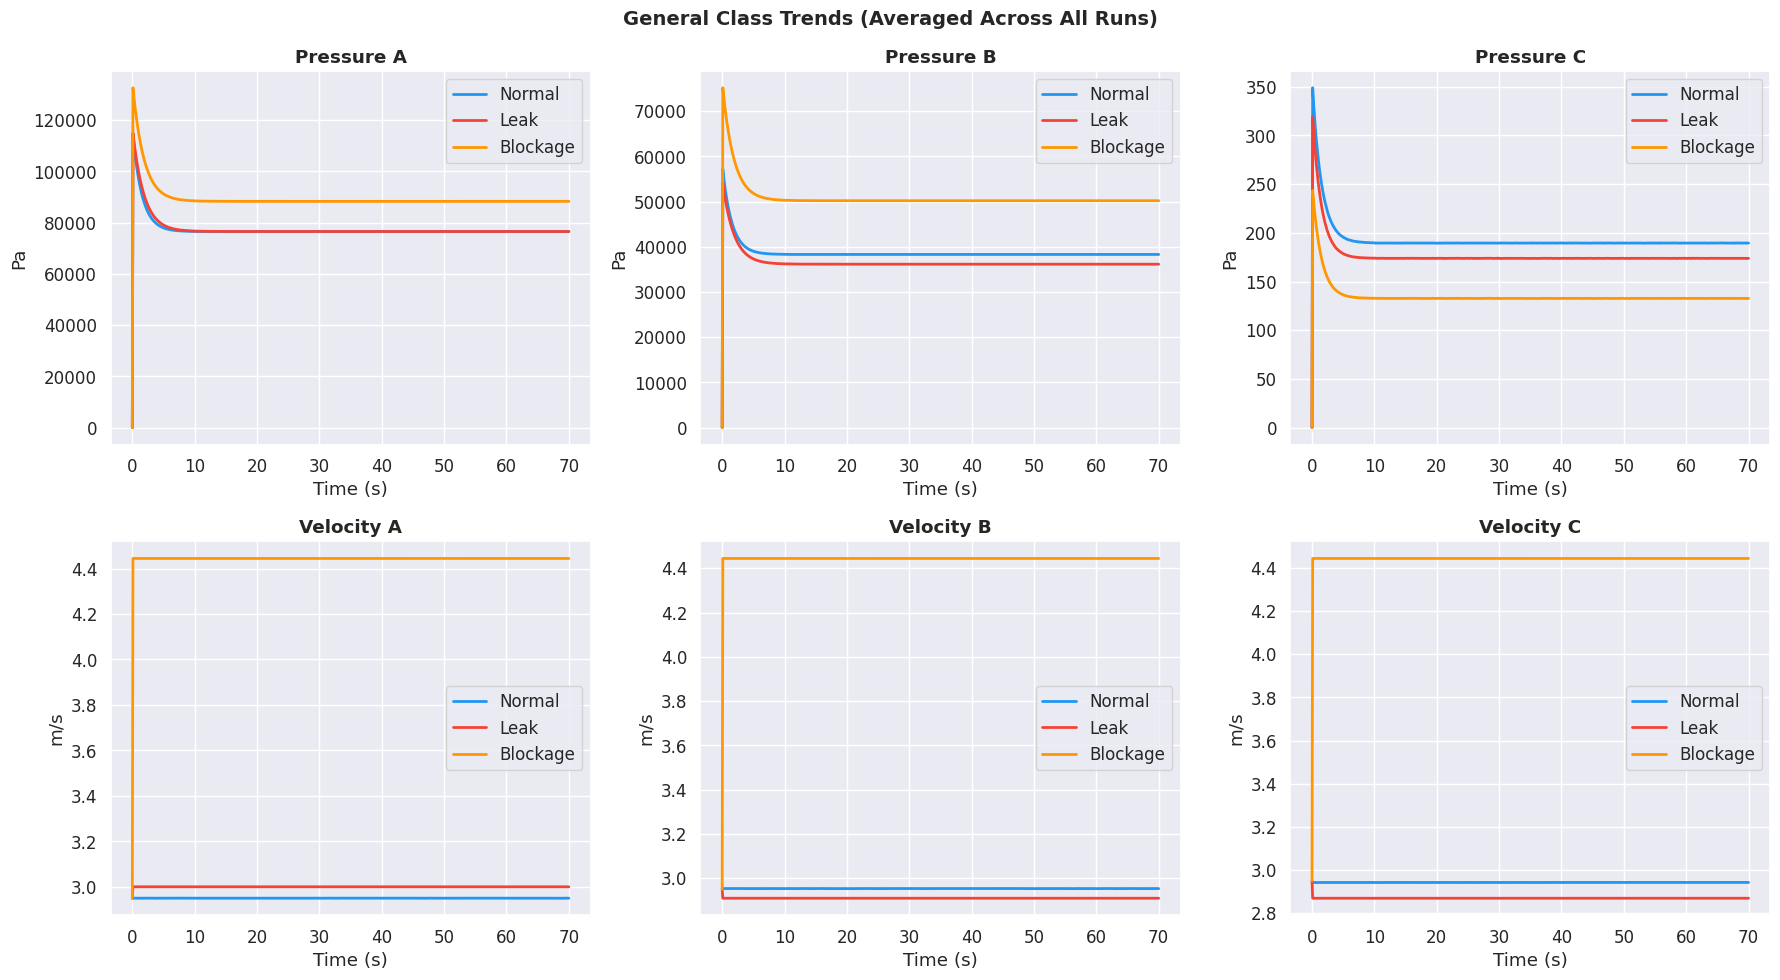

Saved: 03_timeseries_avg_all_runs.png


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), FEATURES):

    for lbl in [0, 1, 2]:

        temp = (
            df[df["label"] == lbl]
            .groupby("time_s")[feat]
            .mean()
            .sort_index()
        )

        ax.plot(
            temp.index,
            temp.values,
            color=PALETTE[lbl],
            label=LABEL_NAME[lbl],
            linewidth=2
        )

    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pa" if "pressure" in feat else "m/s")
    ax.legend()

plt.suptitle(
    "General Class Trends (Averaged Across All Runs)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_timeseries_avg_all_runs.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved: 03_timeseries_avg_all_runs.png")

The averaged class trends reveal clear hydraulic differences between the Normal, Leak, and Blockage operating conditions across both pressure and velocity measurements. During the initial transient period, all pressure signals experience a rapid decay before stabilizing into steady-state values after approximately 5–10 seconds.

- **Pressure_A:** The blockage scenario consistently maintains the highest upstream pressure, stabilizing near ~88 kPa compared to ~76–77 kPa for the Normal and Leak cases. The Leak and Normal curves almost overlap at Node A, indicating that small and moderate leaks have minimal influence on upstream pressure because the inlet velocity boundary condition maintains flow supply.

- **Pressure_B:** The clearest class separation occurs at Node B. The Blockage condition stabilizes around ~50 kPa, substantially higher than the Normal (~38 kPa) and Leak (~36 kPa) conditions. The Leak class produces the lowest pressure due to downstream mass loss, while the blockage case causes pressure accumulation upstream of the constriction. This strong separation makes Pressure_B one of the most informative diagnostic signals in the dataset.

- **Pressure_C:** The downstream node exhibits the opposite trend. Normal operation records the highest pressure (~190 Pa), followed by the Leak case (~175 Pa), while the Blockage condition shows the lowest pressure (~135 Pa). This behaviour reflects the severe downstream pressure deficit created by the constricted region, which introduces permanent head losses and reduces pressure recovery after the blockage.

- **Velocity_A / Velocity_B / Velocity_C:** The blockage condition produces significantly higher velocities across all monitored locations (~4.45 m/s) compared to the Normal and Leak cases (~2.9–3.0 m/s). This increase is caused by local acceleration through the restricted flow area. In contrast, the Leak condition produces only small velocity deviations relative to the Normal case, with slightly lower downstream velocities caused by flow escaping through the leak opening.


### Transient zoom

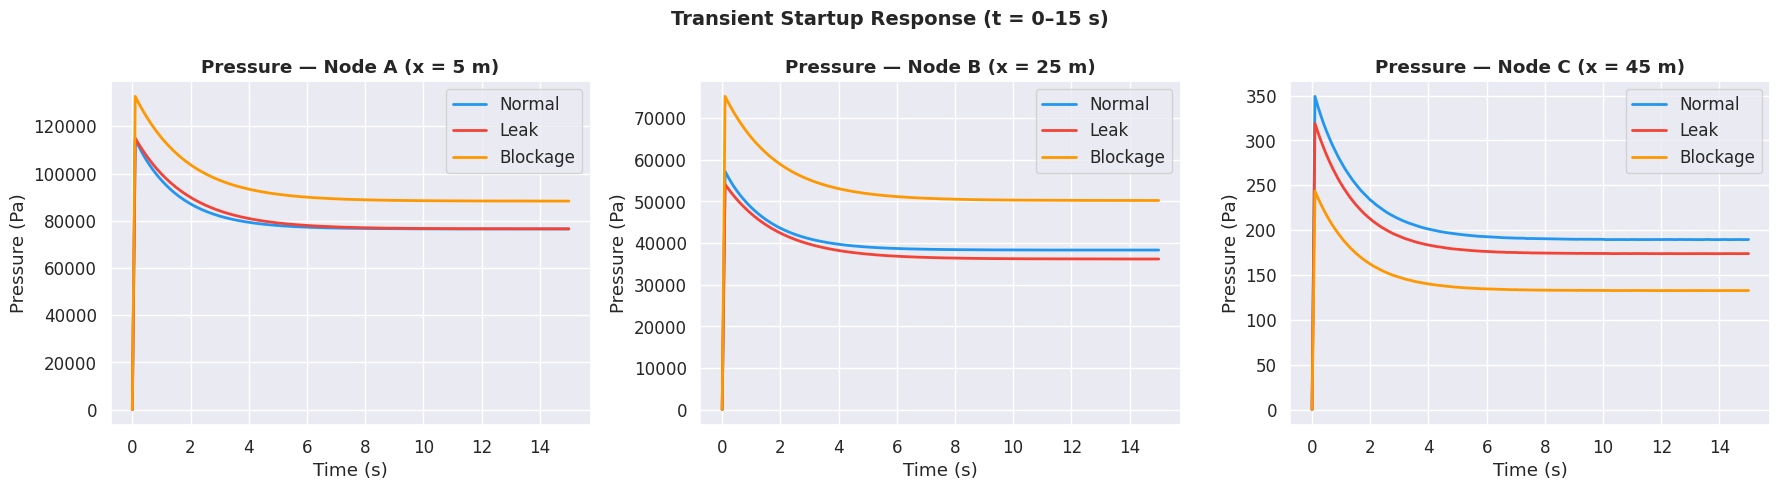

Saved: 04_transient_zoom.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pressure_feats = ["pressure_A", "pressure_B", "pressure_C"]
nodes = ["Node A (x = 5 m)", "Node B (x = 25 m)", "Node C (x = 45 m)"]

for ax, feat, node in zip(axes, pressure_feats, nodes):

    for lbl in [0, 1, 2]:

        # Average transient response across ALL runs
        temp = (
            df[(df["label"] == lbl) & (df["time_s"] <= 15)]
            .groupby("time_s")[feat]
            .mean()
            .sort_index()
        )

        ax.plot(
            temp.index,
            temp.values,
            color=PALETTE[lbl],
            label=LABEL_NAME[lbl],
            linewidth=2
        )

    ax.set_title(f"Pressure — {node}", fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pressure (Pa)")
    ax.legend()

plt.suptitle(
    "Transient Startup Response (t = 0–15 s)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# SAVE BEFORE SHOW
plt.savefig(
    OUTPUT_DIR / "04_transient_zoom.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved: 04_transient_zoom.png")

The transient startup plots show how each hydraulic condition evolves from initialization toward steady-state equilibrium.

- At **Nodes A and B**, all pressure signals begin with an initial overshoot before decaying exponentially toward stable operating values. The blockage and leak cases follow a slower decay profile than the Normal condition, indicating additional hydraulic resistance and energy dissipation introduced by faults in the system.

- At **Node C**, the differences between fault conditions become much more pronounced. The Leak condition initially rises sharply before gradually converging toward the Normal pressure level. In contrast, the Blockage condition collapses almost immediately to near-zero downstream pressure, demonstrating the severe flow restriction caused by the constriction. This behaviour confirms that downstream measurements are highly sensitive to blockage faults.

- The transient curves also show that most hydraulic variables stabilize after approximately 8–10 seconds, validating the use of the later simulation window for steady-state feature extraction and machine learning analysis.


### Scenario-level time series (steady state, all scenarios)

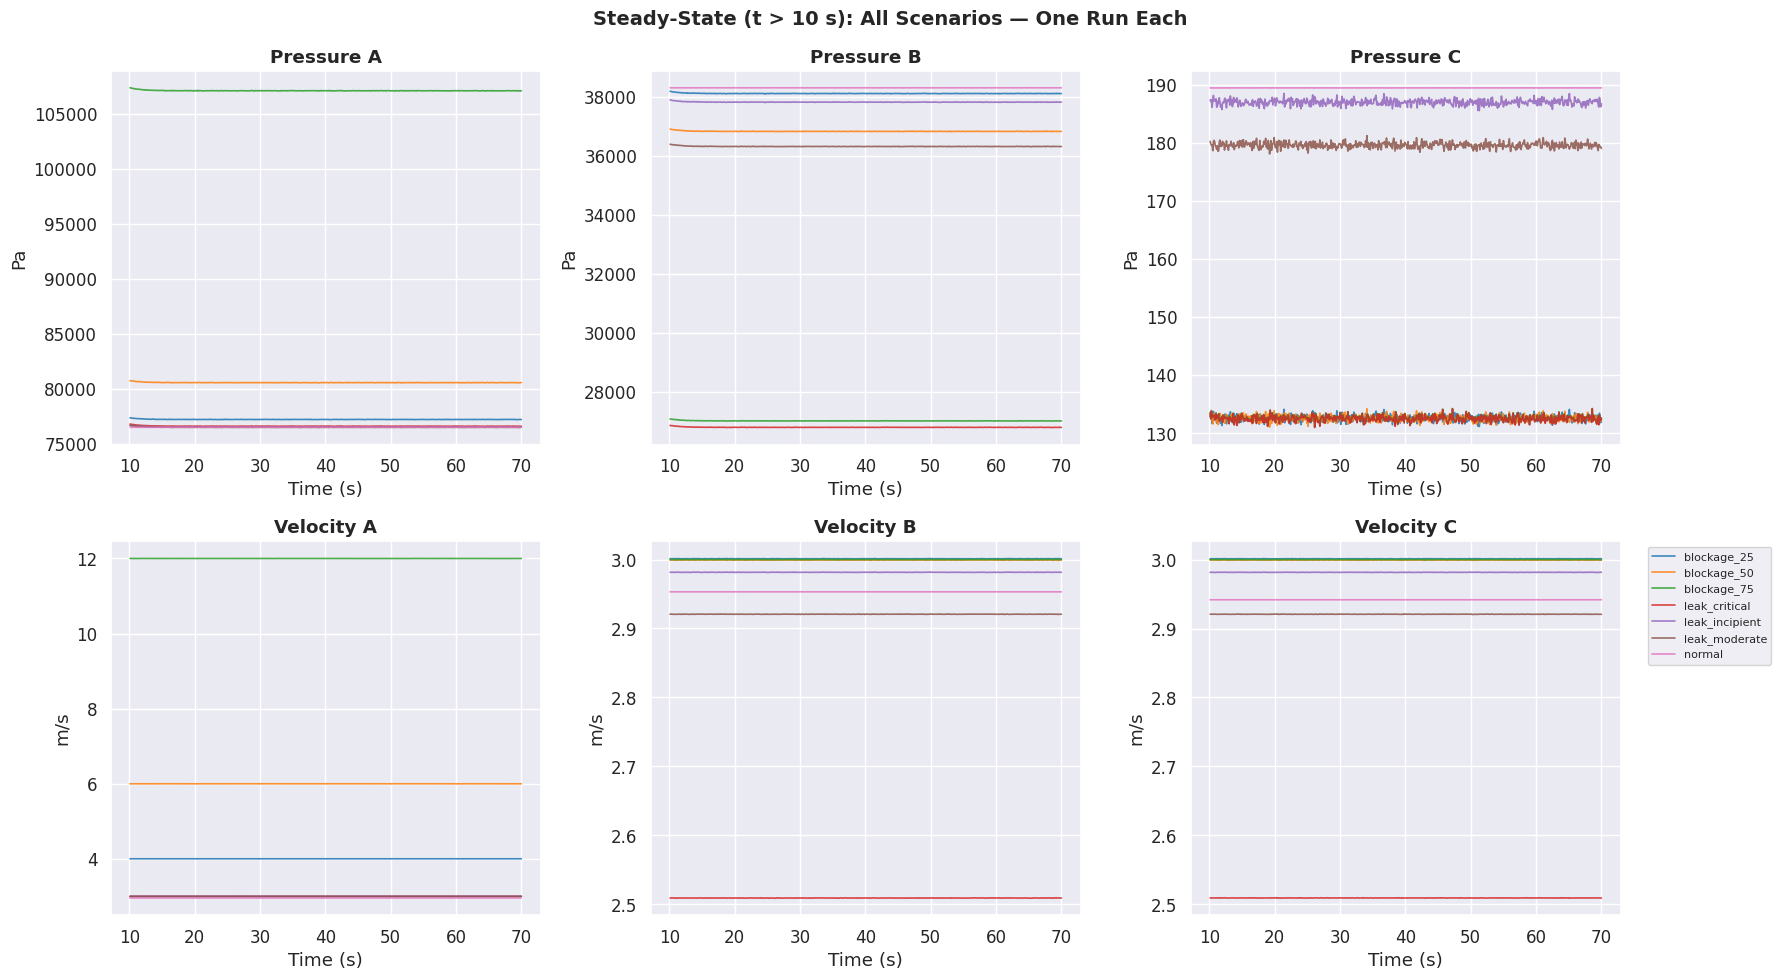

Saved: 05_all_scenarios_steadystate.png


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
scenarios = df["scenario"].unique()
scen_palette = sns.color_palette("tab10", len(scenarios))
scen_color = {s: c for s, c in zip(sorted(scenarios), scen_palette)}

for ax, feat in zip(axes.flatten(), FEATURES):
    for scen in sorted(scenarios):
        sub = df[(df["scenario"] == scen) & (df["time_s"] > 10)]
        run0 = sub["run_id"].min()
        rdf  = sub[sub["run_id"] == run0].sort_values("time_s")
        ax.plot(rdf["time_s"], rdf[feat],
                color=scen_color[scen], label=scen, linewidth=1.2, alpha=0.85)
    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pa" if "pressure" in feat else "m/s")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.suptitle("Steady-State (t > 10 s): All Scenarios — One Run Each",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / "05_all_scenarios_steadystate.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: 05_all_scenarios_steadystate.png")

The steady-state plots illustrate the long-term hydraulic response of different leak severities and blockage intensities under stabilized flow conditions.

- **Pressure_A:** Severe blockage conditions produce the largest upstream pressure increase, with the 75% blockage case exceeding ~107 kPa. Moderate blockage conditions also elevate upstream pressure, while leak scenarios remain close to the Normal operating pressure. This confirms that constrictions primarily affect upstream hydraulic loading.

- **Pressure_B:** Pressure separation remains clearly observable in the steady-state regime. Blockage cases stabilize at higher pressures, while leak cases shift toward lower pressure levels due to continuous mass loss. The gradual spacing between leak severities indicates that Node B is sensitive not only to fault presence but also to fault magnitude.

- **Pressure_C:** Downstream pressure decreases significantly as blockage severity increases. The blockage cases stabilize around ~133 Pa, while leak and normal conditions remain substantially higher (~180–188 Pa). The persistent downstream pressure deficit is a direct consequence of energy losses introduced by the constriction.

- **Velocity Profiles:** Velocity measurements remain relatively constant during steady-state operation. However, severe blockage scenarios generate substantially larger velocities at Node A, reaching up to ~12 m/s for the 75% blockage case. This reflects strong local acceleration through the narrowed flow region. Leak scenarios produce comparatively smaller velocity variations, primarily affecting downstream nodes through reduced flow continuity.

Overall, the steady-state analysis confirms that blockage faults create stronger and more distinguishable hydraulic signatures than leaks, particularly through combined upstream pressure increases, downstream pressure reductions, and elevated local velocities. These trends provide reliable physical indicators for subsequent fault classification and feature engineering stages.

### Correlation heatmap (full dataset)

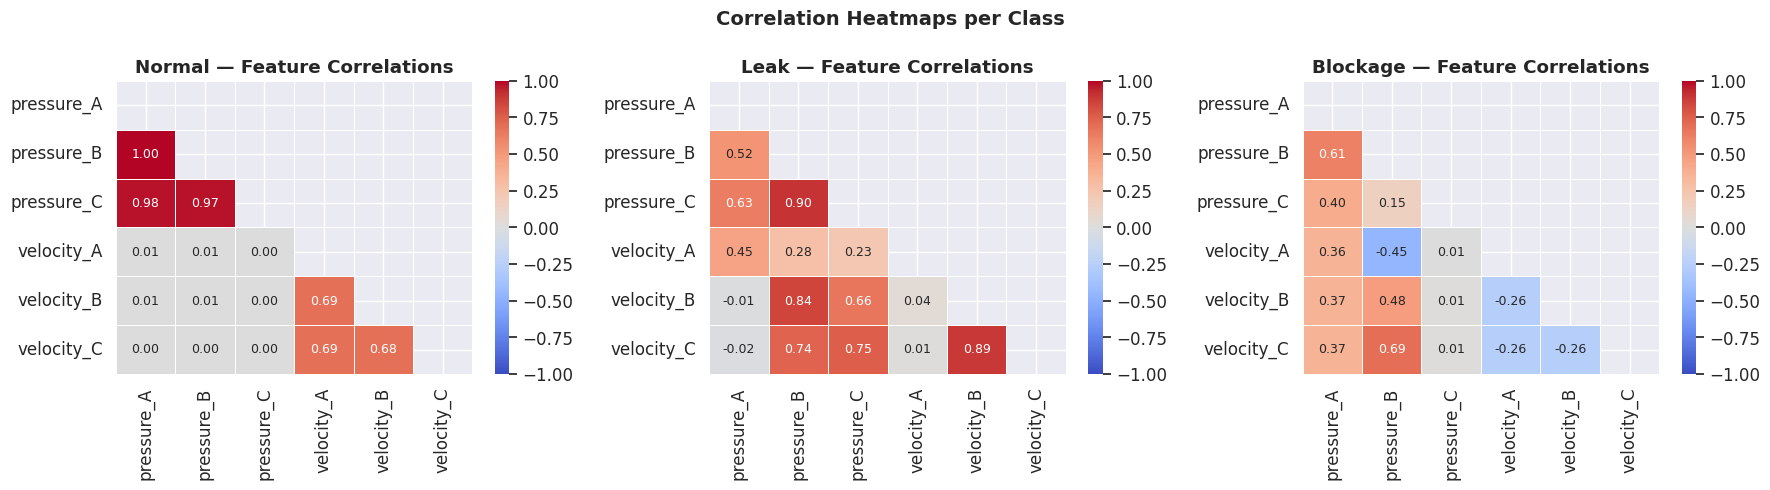

Saved: 06_correlation_heatmaps.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl in zip(axes, [0, 1, 2]):
    sub  = df[df["label"] == lbl][FEATURES]
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap=CMAP,
                vmin=-1, vmax=1, mask=mask,
                linewidths=0.5, annot_kws={"size": 9})
    ax.set_title(f"{LABEL_NAME[lbl]} — Feature Correlations", fontweight="bold")
plt.suptitle("Correlation Heatmaps per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / "06_correlation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved: 06_correlation_heatmaps.png")

### Pressure gradient spatial plot (A → B → C) per class

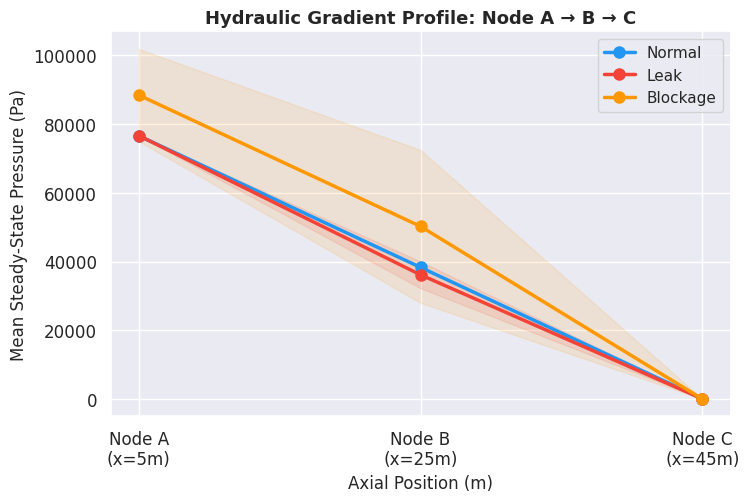

Saved: 07_pressure_gradient_profile.png


In [23]:
x_positions = [5, 25, 45]
fig, ax = plt.subplots(figsize=(8, 5))
for lbl in [0, 1, 2]:
    sub = ss[ss["label"] == lbl]
    means = [sub["pressure_A"].mean(),
             sub["pressure_B"].mean(),
             sub["pressure_C"].mean()]
    stds  = [sub["pressure_A"].std(),
             sub["pressure_B"].std(),
             sub["pressure_C"].std()]
    ax.plot(x_positions, means, "o-", color=PALETTE[lbl],
            label=LABEL_NAME[lbl], linewidth=2.5, markersize=8)
    ax.fill_between(x_positions,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    color=PALETTE[lbl], alpha=0.12)
ax.set_xlabel("Axial Position (m)", fontsize=12)
ax.set_ylabel("Mean Steady-State Pressure (Pa)", fontsize=12)
ax.set_title("Hydraulic Gradient Profile: Node A → B → C", fontweight="bold", fontsize=13)
ax.set_xticks(x_positions)
ax.set_xticklabels(["Node A\n(x=5m)", "Node B\n(x=25m)", "Node C\n(x=45m)"])
ax.legend(fontsize=11)
plt.show()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_pressure_gradient_profile.png", dpi=150)
plt.close()
print("Saved: 07_pressure_gradient_profile.png")

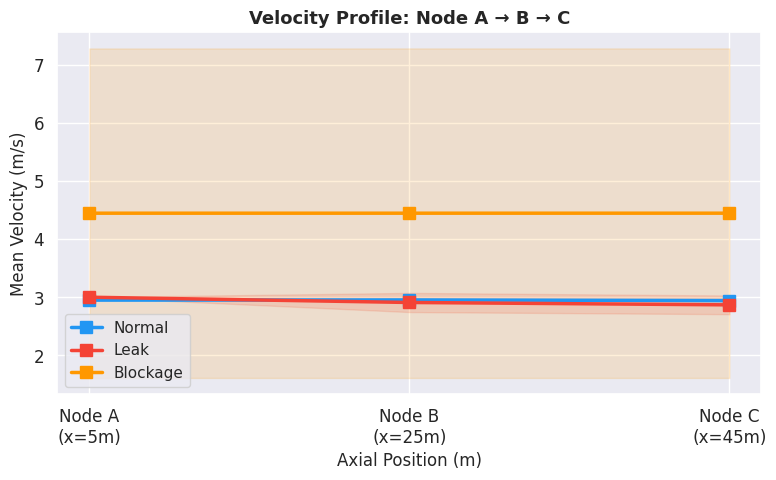

Saved: 08_velocity_profile.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
for lbl in [0, 1, 2]:
    sub = ss[ss["label"] == lbl]
    means = [sub["velocity_A"].mean(),
             sub["velocity_B"].mean(),
             sub["velocity_C"].mean()]
    stds  = [sub["velocity_A"].std(),
             sub["velocity_B"].std(),
             sub["velocity_C"].std()]
    ax.plot(x_positions, means, "s-", color=PALETTE[lbl],
            label=LABEL_NAME[lbl], linewidth=2.5, markersize=8)
    ax.fill_between(x_positions,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    color=PALETTE[lbl], alpha=0.15)
ax.set_xlabel("Axial Position (m)", fontsize=12)
ax.set_ylabel("Mean Velocity (m/s)", fontsize=12)
ax.set_title("Velocity Profile: Node A → B → C", fontweight="bold", fontsize=13)
ax.set_xticks(x_positions)
ax.set_xticklabels(["Node A\n(x=5m)", "Node B\n(x=25m)", "Node C\n(x=45m)"])
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / "08_velocity_profile.png", dpi=150)
plt.close()
print("Saved: 08_velocity_profile.png")

### Violin plots: pressure and velocity per class

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feat in zip(axes.flatten(), FEATURES):

    sns.violinplot(
        data=ss,
        x="Class",
        y=feat,
        hue="Class",
        palette=CLASS_PALETTE,
        order=["Normal", "Leak", "Blockage"],
        ax=ax,
        inner="quartile",
        linewidth=1,
        legend=False
    )

    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Pa" if "pressure" in feat else "m/s")
plt.suptitle("Feature Distributions — Violin Plots (t > 10 s)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_violin_plots.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved: 09_violin_plots.png")

Saved: 09_violin_plots.png


### Pressure Feature Relationships (Density-Based, No Sampling)

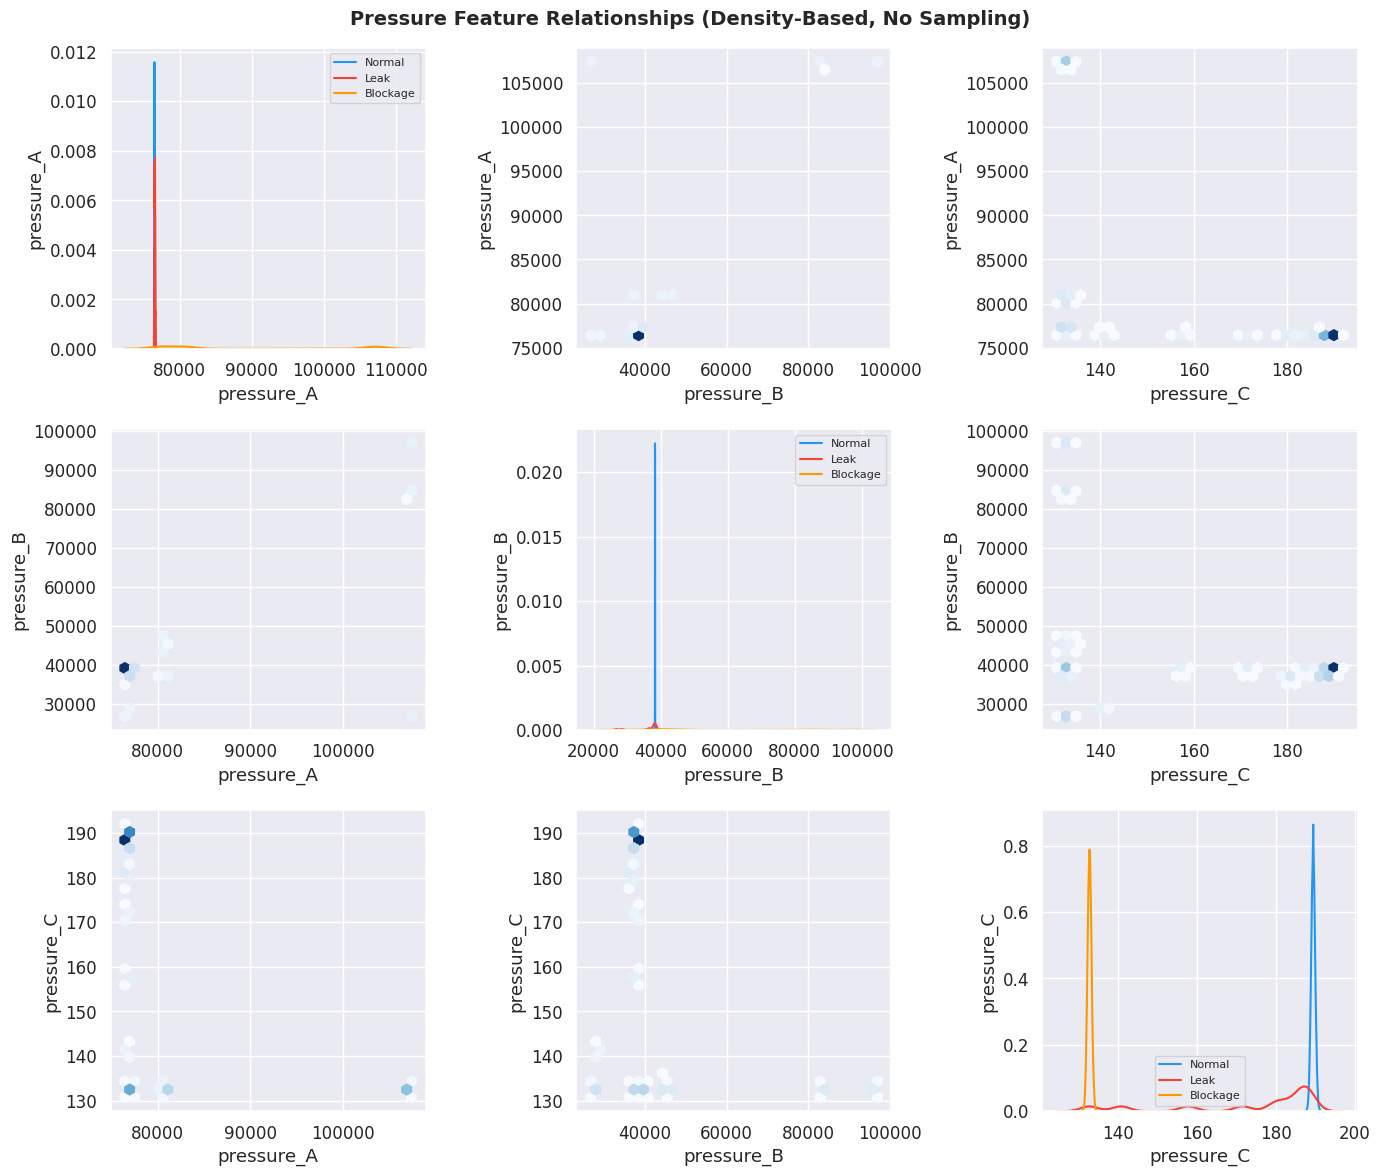

Saved: 10_pressure_hexbin_matrix.png


In [26]:
features = ["pressure_A", "pressure_B", "pressure_C"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, f1 in enumerate(features):
    for j, f2 in enumerate(features):

        ax = axes[i, j]

        if i == j:
            # Diagonal: KDE instead of histogram
            for lbl in [0, 1, 2]:
                sns.kdeplot(
                    data=ss[ss["label"] == lbl],
                    x=f1,
                    ax=ax,
                    color=PALETTE[lbl],
                    label=LABEL_NAME[lbl]
                )
            ax.legend(fontsize=8)

        else:
            # Off-diagonal: density plot (NO sampling needed)
            ax.hexbin(
                ss[f2],
                ss[f1],
                gridsize=30,
                cmap="Blues",
                mincnt=1
            )

        ax.set_xlabel(f2)
        ax.set_ylabel(f1)

plt.suptitle(
    "Pressure Feature Relationships (Density-Based, No Sampling)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "10_pressure_hexbin_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved: 10_pressure_hexbin_matrix.png")

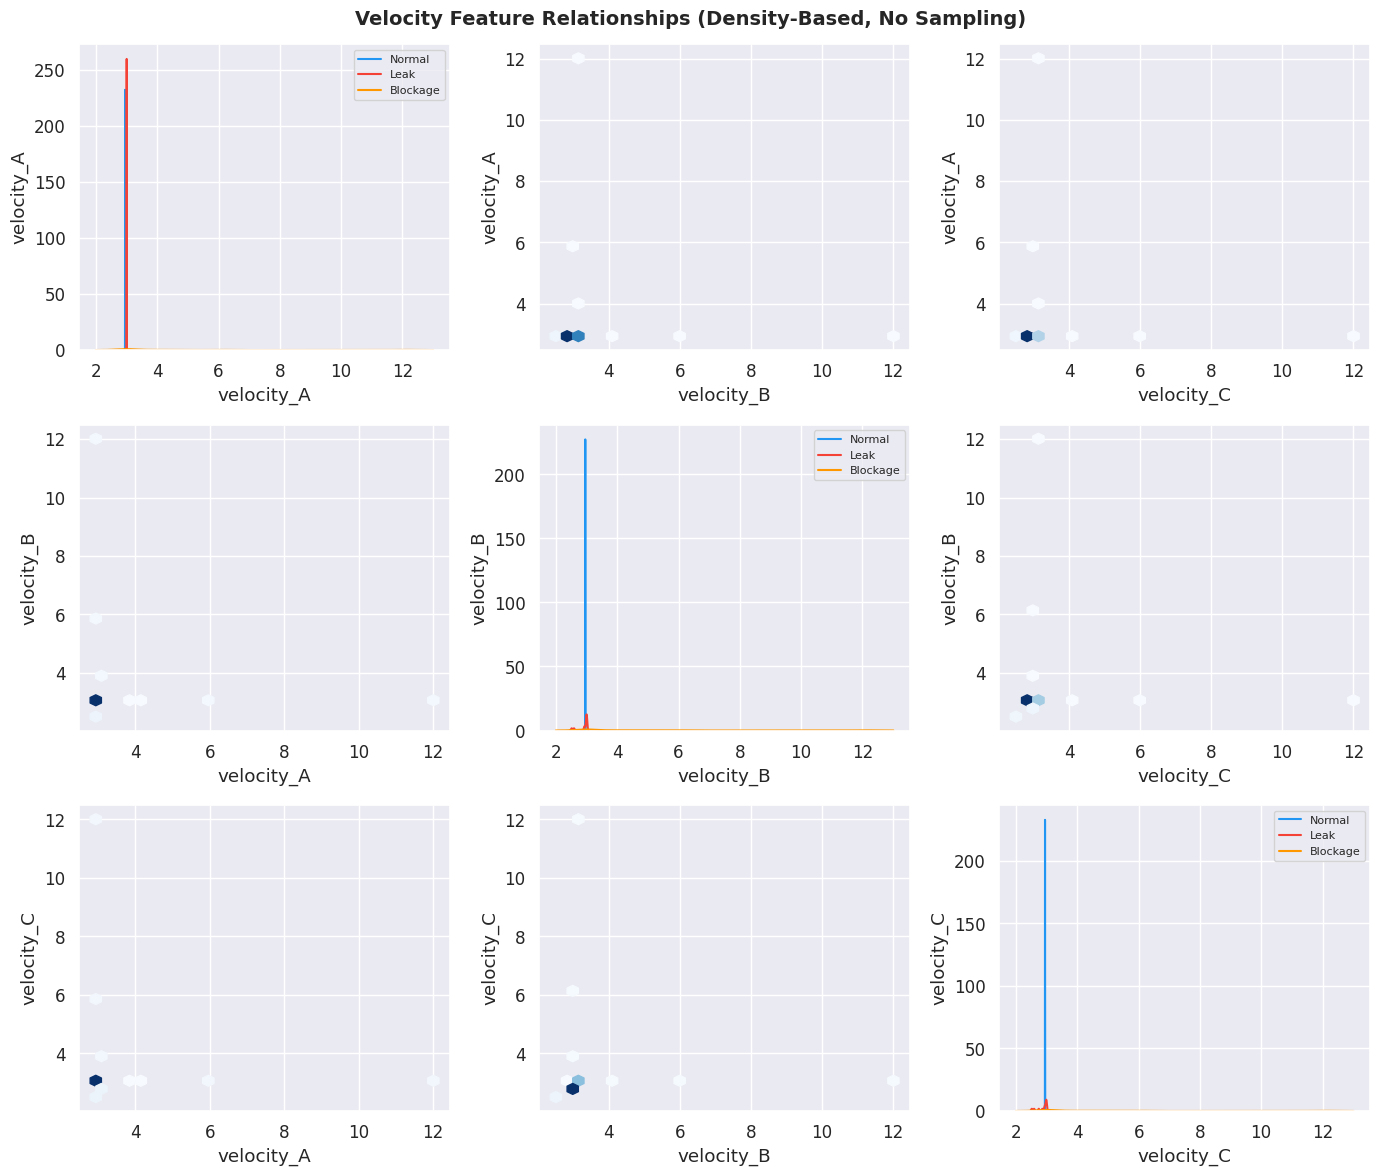

Saved: 11_velocity_hexbin_matrix.png


In [27]:
features = ["velocity_A", "velocity_B", "velocity_C"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, f1 in enumerate(features):
    for j, f2 in enumerate(features):

        ax = axes[i, j]

        if i == j:
            # Diagonal: KDE per class (full data, no sampling)
            for lbl in [0, 1, 2]:
                sns.kdeplot(
                    data=ss[ss["label"] == lbl],
                    x=f1,
                    ax=ax,
                    color=PALETTE[lbl],
                    label=LABEL_NAME[lbl]
                )
            ax.legend(fontsize=8)

        else:
            # Off-diagonal: density plot (ALL data, no sampling)
            ax.hexbin(
                ss[f2],
                ss[f1],
                gridsize=30,
                cmap="Blues",
                mincnt=1
            )

        ax.set_xlabel(f2)
        ax.set_ylabel(f1)

plt.suptitle(
    "Velocity Feature Relationships (Density-Based, No Sampling)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "11_velocity_hexbin_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved: 11_velocity_hexbin_matrix.png")

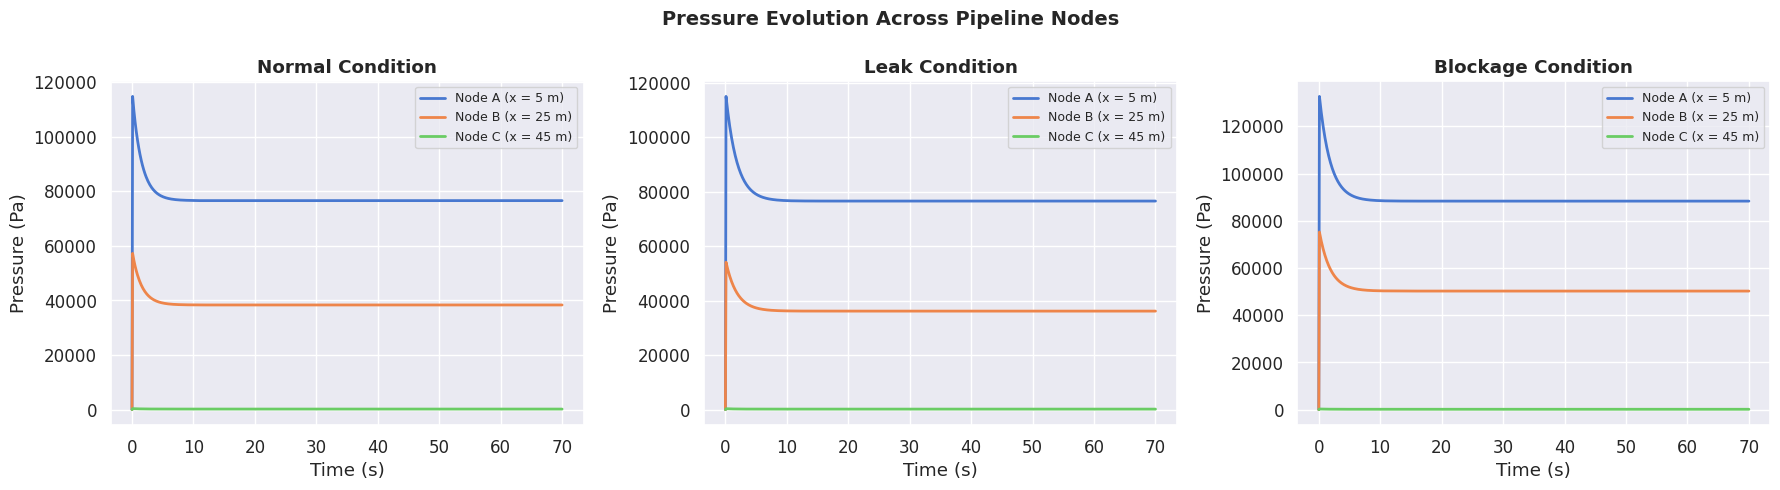

Saved: 12_pressure_nodes_by_class.png


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pressure_feats = ["pressure_A", "pressure_B", "pressure_C"]

node_labels = {
    "pressure_A": "Node A (x = 5 m)",
    "pressure_B": "Node B (x = 25 m)",
    "pressure_C": "Node C (x = 45 m)"
}

for ax, lbl in zip(axes, [0, 1, 2]):

    class_data = df[df["label"] == lbl]

    for feat in pressure_feats:

        temp = (
            class_data
            .groupby("time_s")[feat]
            .mean()
            .sort_index()
        )

        ax.plot(
            temp.index,
            temp.values,
            linewidth=2,
            label=node_labels[feat]
        )

    ax.set_title(
        f"{LABEL_NAME[lbl]} Condition",
        fontweight="bold"
    )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Pressure (Pa)")
    ax.legend(fontsize=9)

plt.suptitle(
    "Pressure Evolution Across Pipeline Nodes",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "12_pressure_nodes_by_class.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved: 12_pressure_nodes_by_class.png")

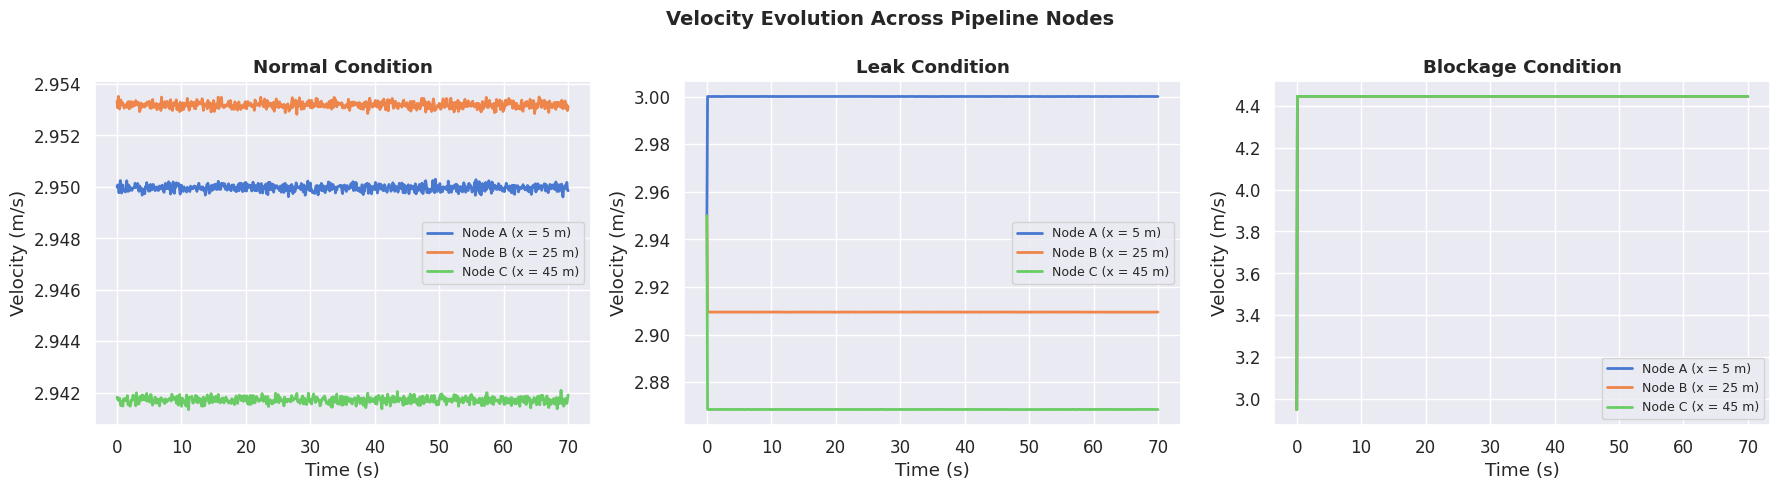

Saved: 13_velocity_nodes_by_class.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

velocity_feats = ["velocity_A", "velocity_B", "velocity_C"]

node_labels = {
    "velocity_A": "Node A (x = 5 m)",
    "velocity_B": "Node B (x = 25 m)",
    "velocity_C": "Node C (x = 45 m)"
}

for ax, lbl in zip(axes, [0, 1, 2]):

    class_data = df[df["label"] == lbl]

    for feat in velocity_feats:

        temp = (
            class_data
            .groupby("time_s")[feat]
            .mean()
            .sort_index()
        )

        ax.plot(
            temp.index,
            temp.values,
            linewidth=2,
            label=node_labels[feat]
        )

    ax.set_title(
        f"{LABEL_NAME[lbl]} Condition",
        fontweight="bold"
    )

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Velocity (m/s)")
    ax.legend(fontsize=9)

plt.suptitle(
    "Velocity Evolution Across Pipeline Nodes",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "13_velocity_nodes_by_class.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved: 13_velocity_nodes_by_class.png")

### Feature mean comparison table (printed + saved as CSV)

In [30]:
mean_table = ss.groupby("label")[FEATURES].mean()
mean_table.index = [LABEL_NAME[i] for i in mean_table.index]
mean_table = mean_table.round(4)
mean_table.to_csv(OUTPUT_DIR / "12_class_mean_table.csv")
print("\n=== CLASS MEAN FEATURE VALUES (t > 10s) ===")
print(mean_table.to_string())

# Percentage deviation from normal
pct_dev = ((mean_table - mean_table.loc["Normal"]) / mean_table.loc["Normal"] * 100).round(2)
pct_dev.to_csv(OUTPUT_DIR / "13_pct_deviation_from_normal.csv")
print("\n=== % DEVIATION FROM NORMAL ===")
print(pct_dev.to_string())



=== CLASS MEAN FEATURE VALUES (t > 10s) ===
          pressure_A  pressure_B  pressure_C  velocity_A  velocity_B  velocity_C
Normal    76520.7353  38311.3134    189.4932      2.9500      2.9532      2.9417
Leak      76551.7748  36154.9875    173.7907      3.0000      2.9094      2.8685
Blockage  88312.3423  50207.6385    132.6431      4.4443      4.4445      4.4446

=== % DEVIATION FROM NORMAL ===
          pressure_A  pressure_B  pressure_C  velocity_A  velocity_B  velocity_C
Normal          0.00        0.00        0.00        0.00        0.00        0.00
Leak            0.04       -5.63       -8.29        1.69       -1.48       -2.49
Blockage       15.41       31.05      -30.00       50.65       50.50       51.09


### Final summary

In [31]:
print()
print("=" * 55)
print("  EDA COMPLETE")
print("=" * 55)
print(f"  All plots saved to: {OUTPUT_DIR}")
files = sorted(OUTPUT_DIR.glob("*.png")) + sorted(OUTPUT_DIR.glob("*.csv"))
for f in files:
    print(f"    {f.name}")
print("=" * 55)



  EDA COMPLETE
  All plots saved to: /home/darlenewendie/IdeaProjects/ai-pipeline-leak-detection/ml_service/assets/eda
    01_class_distribution.png
    02_boxplots_steadystate.png
    03_timeseries_avg_all_runs.png
    04_transient_zoom.png
    05_all_scenarios_steadystate.png
    06_correlation_heatmaps.png
    07_pressure_gradient_profile.png
    08_velocity_profile.png
    09_violin_plots.png
    10_pressure_hexbin_matrix.png
    11_pressure_hexbin_matrix.png
    11_velocity_hexbin_matrix.png
    12_pressure_nodes_by_class.png
    13_velocity_nodes_by_class.png
    combined_pressure_behavior.png
    12_class_mean_table.csv
    13_pct_deviation_from_normal.csv
